In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import ta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("Data/cac40_clean_format.csv", parse_dates=["Datetime"])

# Trier d'abord par Ticker, puis par Datetime
df.sort_values(by=["Ticker", "Datetime"], inplace=True)



KeyboardInterrupt: 

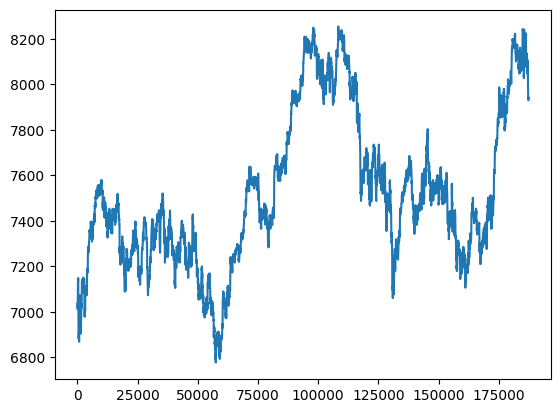

In [ ]:
df_wide = df.pivot(index=["Datetime", "Ticker"], columns="Price", values="Value").reset_index()
df_wide.columns.name = None  # Enlever le nom de l'index multi-colonne
df_wide.rename(columns={"Open": "O", "High": "H", "Low": "L", "Close": "C", "Volume": "V"}, inplace=True)  # Renommer pour simplifier
plt.plot(df_wide[df_wide["Ticker"]=="^FCHI"]['C'])
df_wide=df_wide[df_wide["Ticker"]!="^FCHI"]
df=df_wide.copy()


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scalers = {}  # Stocker les scalers
features = ["O", "H", "L", "C", "V"]

# Normalisation par ticker
for ticker in df["Ticker"].unique():
    scaler = MinMaxScaler()
    mask = df["Ticker"] == ticker
    df.loc[mask, features] = scaler.fit_transform(df.loc[mask, features])
    scalers[ticker] = scaler  # Stocker le scaler pour usage futur

df.describe()


,C,H,L,O,V
count,182766.000000,182766.000000,182766.000000,182766.000000,182766.000000
mean,0.443680,0.440422,0.449367,0.444681,0.075709
std,0.251631,0.251727,0.249876,0.251243,0.075784
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.225632,0.221253,0.234480,0.227017,0.030384
50%,0.426429,0.422382,0.433058,0.427661,0.057208
75%,0.642546,0.639258,0.647536,0.643485,0.098672
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_wide.describe()

,C,H,L,O,V
count,182766.000000,182766.000000,182766.000000,182766.000000,1.827660e+05
mean,157.058004,157.514463,156.590319,157.056392,7.648262e+04
std,339.705069,340.732337,338.644049,339.699686,1.252908e+05
min,2.384000,2.397000,2.323000,2.384000,0.000000e+00
25%,29.700001,29.780001,29.620001,29.700001,1.197800e+04
50%,59.799999,59.950001,59.660000,59.810001,3.173850e+04
75%,146.399994,146.750000,146.000000,146.399994,8.878125e+04
max,2892.000000,2957.000000,2884.000000,2926.000000,3.885897e+06


In [ ]:
df["SMA_10"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.sma_indicator(x, window=10))
df["SMA_50"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.sma_indicator(x, window=50))
df["RSI_14"] = df.groupby("Ticker")["C"].transform(lambda x: ta.momentum.rsi(x, window=14))
df["MACD"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.macd(x))
df["MACD_Signal"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.macd_signal(x))

df.dropna(inplace=True)  # Supprime les lignes avec NaN
df.head()

,Datetime,Ticker,C,H,L,O,V,SMA_10,SMA_50,RSI_14,MACD,MACD_Signal
1924,2023-03-21 12:00:00+00:00,AC.PA,0.074058,0.067102,0.078913,0.081046,0.087310,0.054482,0.047908,67.776551,0.006533,0.001400
1925,2023-03-21 12:00:00+00:00,ACA.PA,0.074821,0.073624,0.105682,0.078852,0.095827,0.059009,0.071337,56.905435,0.002773,-0.004974
1926,2023-03-21 12:00:00+00:00,AI.PA,0.075259,0.066249,0.077167,0.073481,0.056407,0.071094,0.035998,64.488811,0.012589,0.011302
1927,2023-03-21 12:00:00+00:00,AIR.PA,0.089000,0.083086,0.116407,0.092698,0.023356,0.065800,0.049313,67.337546,0.012343,0.004500
1928,2023-03-21 12:00:00+00:00,BN.PA,0.206401,0.203467,0.217351,0.204724,0.134507,0.189935,0.175900,66.075911,0.006779,0.003898


In [ ]:
df["Return_1h"] = df.groupby("Ticker")["C"].pct_change(1).shift(-1)  # Variation future du prix
df["Target"] = (df["Return_1h"] > 0).astype(int)  # 1 si hausse, 0 si baisse

df.dropna(inplace=True)  # Supprime les NaN


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

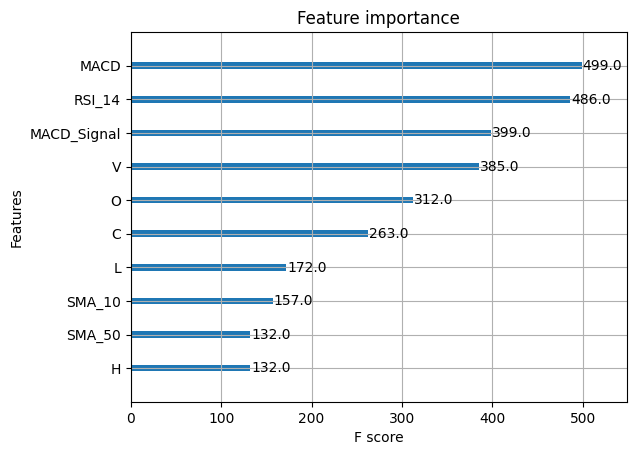

In [ ]:
df["Ticker"]=df["Ticker"].astype("category")
X = df[["O", "H", "L", "C", "V", "SMA_10", "SMA_50", "RSI_14", "MACD", "MACD_Signal"]]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,shuffle=False)

model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,enable_categorical=True)
model.fit(X_train, y_train,)

xgb.plot_importance(model)

In [ ]:
# Prédiction
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_labels = (y_pred > 0.5).astype(int)
# Évaluation
accuracy = accuracy_score(y_test, y_pred_labels)
X_test["Prediction"] = y_pred
X_test["Prediction_hausse"] = y_pred_proba

In [ ]:
accuracy

0.5613642021409012

In [ ]:
initial_cash = 10000

simulation fifo ALL-In

cash:5.5979912281, trade:1278,portefeuille:11586.033102273937
rentabilité:15.860331022739373%
Rentabilité annuelle estimée : 0.4448970768324638%


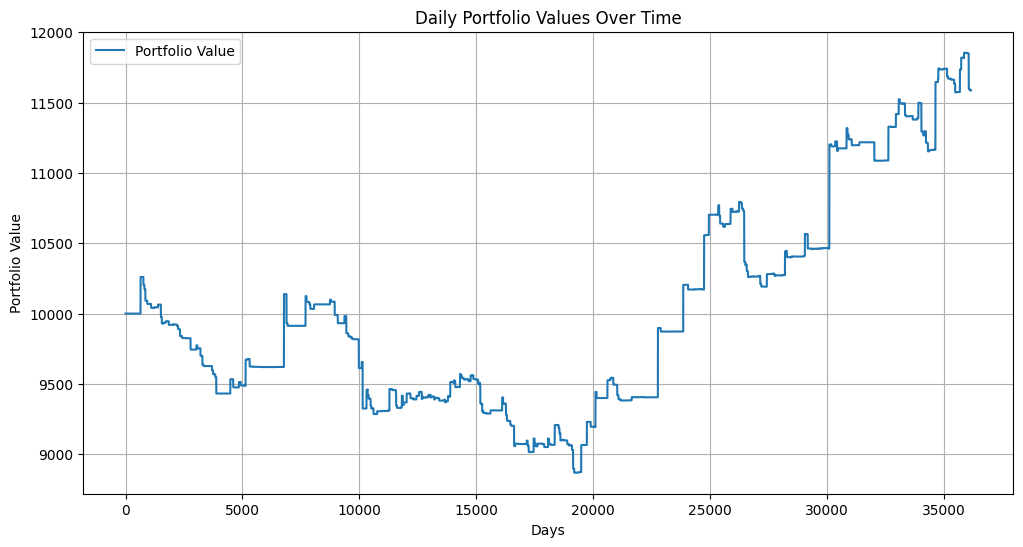

In [ ]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


Simulation Fifo ALL-In stop loss

cash: 11.120925426464964, trade: 1227, portefeuille: 10497.976027011853
rentabilité: 4.979760270118532%
Rentabilité annuelle estimée : 0.12918198742158404%


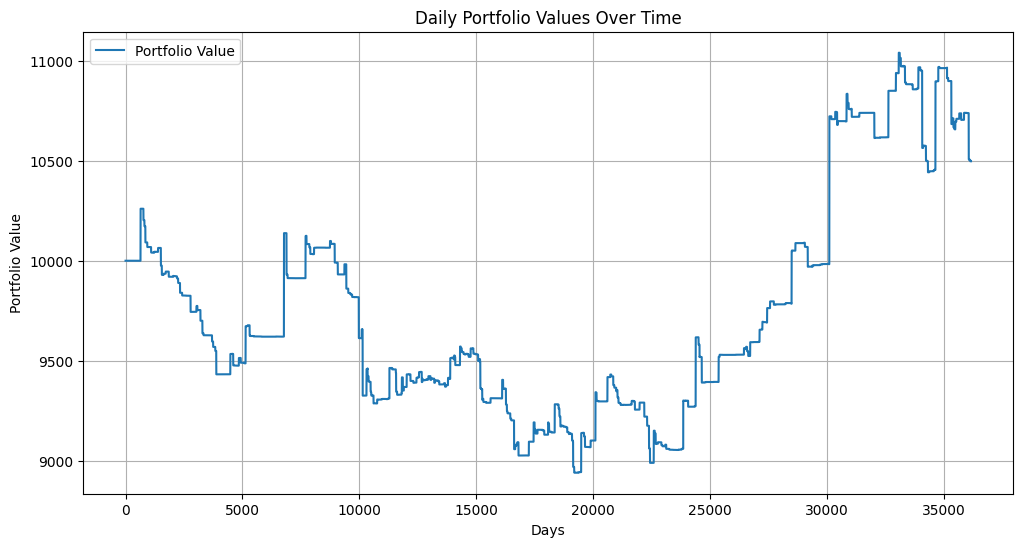

In [ ]:
# Simulation parameters
trade = 0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, quantité)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

# Paramètres Stop Loss et Take Profit
stop_loss_pct = 0.03  # 3% de perte max avant vente forcée
take_profit_pct = 10  # 5% de gain avant prise de profit

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    
    # Achat
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        positions[ticker] = (price, cash // price)  # Enregistre prix d'achat et quantité
        cash -= price * positions[ticker][1]
        trade += 1
        
    # Vente conditionnelle
    elif ticker in positions:
        buy_price, quantity = positions[ticker]
        
        # Vérification du Stop Loss
        if price <= buy_price * (1 - stop_loss_pct):  # Stop Loss atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vérification du Take Profit
        elif price >= buy_price * (1 + take_profit_pct):  # Take Profit atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vente standard si prédiction négative
        elif row["Prediction"] == 0:
            cash += price * quantity
            positions.pop(ticker)
    
    daily_portfolio_values.append(cash + sum([a * b for a, b in positions.values()]))

print(f"cash: {cash}, trade: {trade}, portefeuille: {daily_portfolio_values[-1]}")
print(f"rentabilité: {(daily_portfolio_values[-1] - initial_cash) / initial_cash * 100}%")

print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


Simulation fifo ALL-IN TP/SL

In [ ]:
# Simulation parameters
trade = 0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, quantité)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

# Paramètres Stop Loss et Take Profit
stop_loss_pct = 0.03  # 3% de perte max avant vente forcée
take_profit_pct = 0.05  # 5% de gain avant prise de profit

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    
    # Achat
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        positions[ticker] = (price, cash // price)  # Enregistre prix d'achat et quantité
        cash -= price * positions[ticker][1]
        trade += 1
        
    # Vente conditionnelle
    elif ticker in positions:
        buy_price, quantity = positions[ticker]
        
        # Vérification du Stop Loss
        if price <= buy_price * (1 - stop_loss_pct):  # Stop Loss atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vérification du Take Profit
        elif price >= buy_price * (1 + take_profit_pct):  # Take Profit atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vente standard si prédiction négative
        elif row["Prediction"] == 0:
            cash += price * quantity
            positions.pop(ticker)
    
    daily_portfolio_values.append(cash + sum([a * b for a, b in positions.values()]))

print(f"cash: {cash}, trade: {trade}, portefeuille: {daily_portfolio_values[-1]}")
print(f"rentabilité: {(daily_portfolio_values[-1] - initial_cash) / initial_cash * 100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


KeyboardInterrupt: 

Simulation fraction mobile

cash:1455.7957010269165, trade:4201,portefeuille:10319.030752182007
rentabilité:3.1903075218200683%
Rentabilité annuelle estimée : 0.0816761818362024%


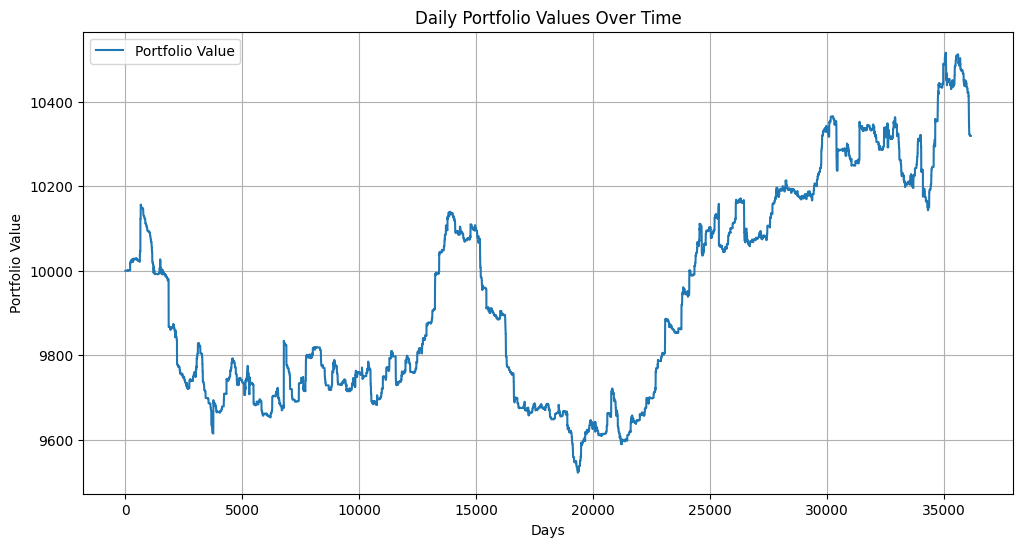

In [ ]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

fraction=0.3

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    max_cash = fraction * cash
    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulaton Fraction fixe

cash:-26864.997821092606, trade:4623,portefeuille:16569.781883001328
rentabilité:65.69781883001328%
Rentabilité annuelle estimée : 2.5342069697462266%


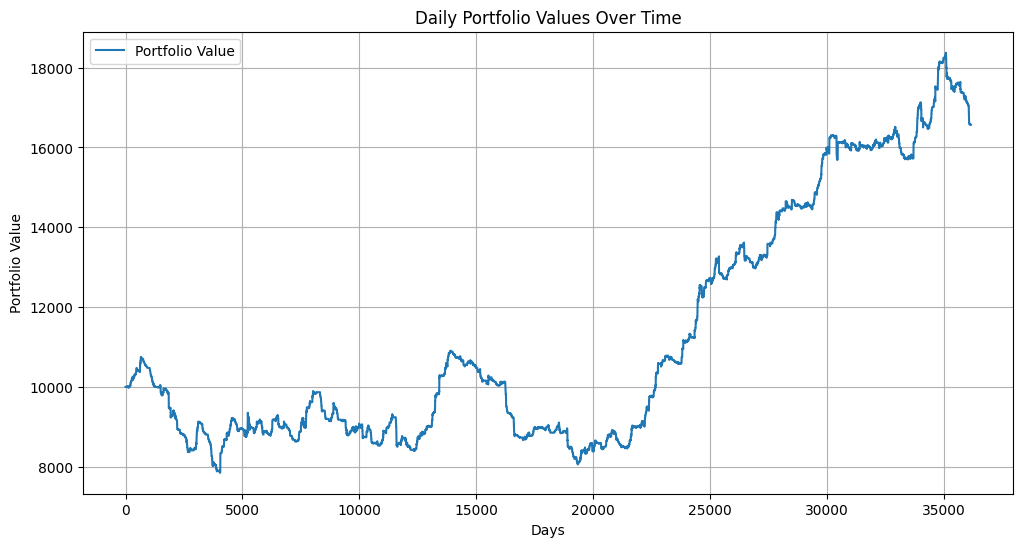

In [ ]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

fraction=0.3
max_cash = fraction * initial_cash
for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]

    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        if max_cash>cash:
            positions[ticker] = (price, cash//price)
        else:positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation risque fixe

cash: 10.768636465072618, trade: 1764, portefeuille: 9255.653844594955
rentabilité: -7.443461554050446%
Rentabilité annuelle estimée : -0.17582818245783838%


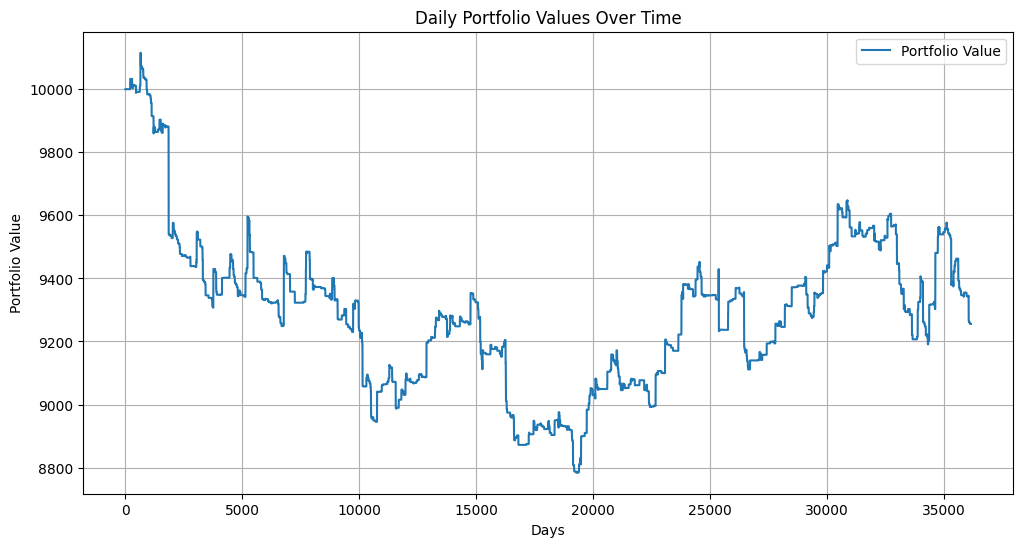

In [ ]:
# Simulation parameters
trade = 0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, quantité)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

fixed_risk=0.02
# Paramètres Stop Loss et Take Profit
stop_loss_pct = 0.05  # 3% de perte max avant vente forcée
take_profit_pct = 10  # 5% de gain avant prise de profit

max_investment = initial_cash * fixed_risk/stop_loss_pct

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    
    # Achat
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        if cash>max_investment:
            positions[ticker] = (price, max_investment // price)
        else:positions[ticker] = (price, cash // price)  # Enregistre prix d'achat et quantité
        cash -= price * positions[ticker][1]
        trade += 1
        
    # Vente conditionnelle
    elif ticker in positions:
        buy_price, quantity = positions[ticker]
        
        # Vérification du Stop Loss
        if price <= buy_price * (1 - stop_loss_pct):  # Stop Loss atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vérification du Take Profit
        elif price >= buy_price * (1 + take_profit_pct):  # Take Profit atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vente standard si prédiction négative
        elif row["Prediction"] == 0:
            cash += price * quantity
            positions.pop(ticker)
    
    daily_portfolio_values.append(cash + sum([a * b for a, b in positions.values()]))

print(f"cash: {cash}, trade: {trade}, portefeuille: {daily_portfolio_values[-1]}")
print(f"rentabilité: {(daily_portfolio_values[-1] - initial_cash) / initial_cash * 100}%")

print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


Simulation Kelly Criterion

cash:8081.650002002716, trade:3661,portefeuille:10428.08999300003
rentabilité:4.280899930000305%
Rentabilité annuelle estimée : 0.11048302957323441%


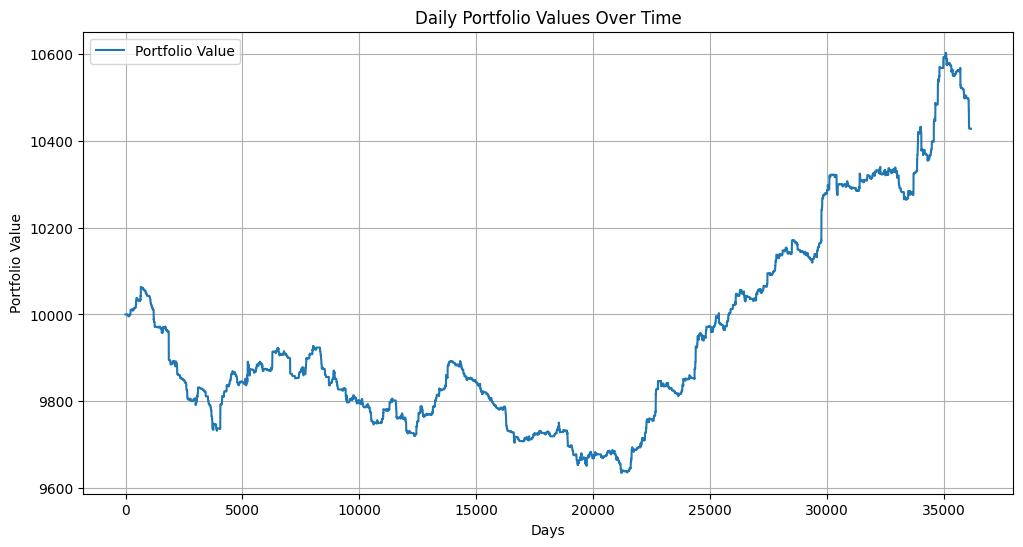

In [ ]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

ratio_profit_perte=2

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    max_cash = (2 * row["Prediction_hausse"]-1)/ratio_profit_perte * cash
    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation investissement dynamique basé sur le marché

cash:9089.933970212931, trade:1090,portefeuille:10102.37897753715
rentabilité:1.023789775371497%
Rentabilité annuelle estimée : 0.025791606576188064%


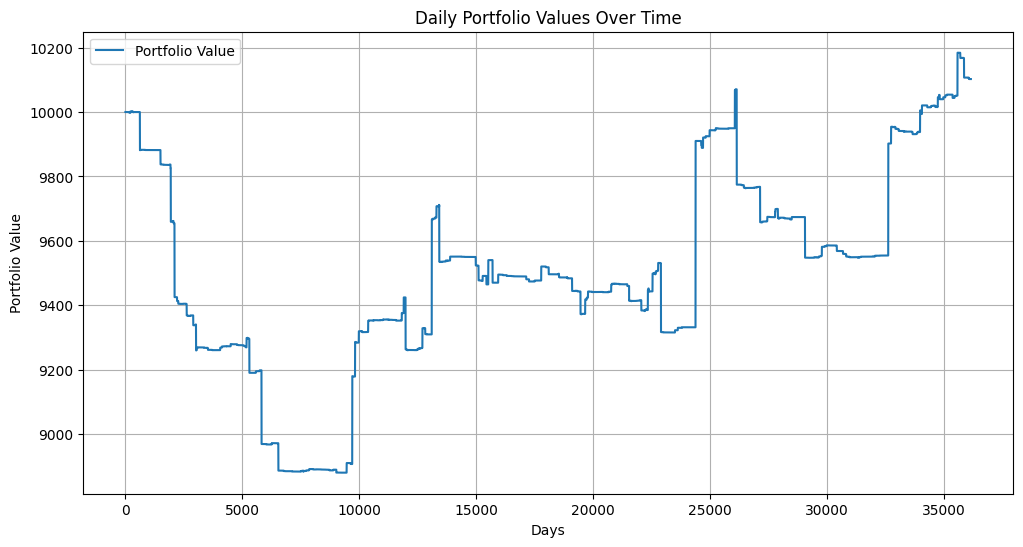

In [ ]:
df_wide["ROC_10"] = df_wide.groupby("Ticker")["C"].transform(lambda x: ta.momentum.ROCIndicator(x, window=10).roc())
scaler = MinMaxScaler()
# Calcul de la somme des momentums (ROC_10) par Ticker
df_wide["ROC_10_sum"] = df_wide.groupby("Ticker")["ROC_10"].transform("sum")
# Normalisation en divisant chaque momentum par la somme des momentums pour chaque Ticker
df_wide["ROC_10_normalized"] = df_wide["ROC_10"] / df_wide["ROC_10_sum"]

# Optionnel : Supprimer la colonne temporaire "ROC_10_sum" si tu n'en as plus besoin
df_wide.drop(columns=["ROC_10_sum"], inplace=True)

# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

ratio_profit_perte=2

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    max_cash =df_wide.iloc[len(df_wide)-len(X_test)-2+i]["ROC_10_normalized"] * cash
    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation fifo Livio

In [ ]:
df_wide.head()

,Datetime,Ticker,C,H,L,O,V,ROC_10,ROC_10_normalized
0,2023-03-14 08:00:00+00:00,AC.PA,29.330000,29.330000,28.990000,29.049999,0.0,NaN,NaN
1,2023-03-14 08:00:00+00:00,ACA.PA,10.588000,10.690000,10.514000,10.634000,0.0,NaN,NaN
2,2023-03-14 08:00:00+00:00,AI.PA,133.690903,134.000000,133.072739,133.563629,0.0,NaN,NaN
3,2023-03-14 08:00:00+00:00,AIR.PA,119.599998,119.720001,118.160004,118.160004,0.0,NaN,NaN
4,2023-03-14 08:00:00+00:00,BN.PA,54.299999,54.450001,54.020000,54.330002,0.0,NaN,NaN


(23.684999465942383, 0.0) 27.38999938964844 GLE.PA
(153.5, 14.0) 161.85000610351562 HO.PA
(1970.5, 0.0) 2086.0 RMS.PA
(224.8000030517578, 0.0) 244.4499969482422 KER.PA
(25.364999771118164, 0.0) 26.674999237060547 GLE.PA
(2.4730000495910645, 1.0) 2.657999992370605 VIV.PA
(33.52000045776367, 0.0) 35.36000061035156 CS.PA
(234.5, 0.0) 253.1999969482422 EL.PA
(342.6000061035156, 0.0) 365.75 OR.PA
(245.8500061035156, 0.0) 259.6499938964844 KER.PA
(2518.0, 0.0) 2669.0 RMS.PA
(48.79999923706055, 0.0) 51.5 ERF.PA
(37.310001373291016, 0.0) 40.66999816894531 DSY.PA
(25.5, 0.0) 27.030000686645508 MT.AS
(55.650001525878906, 0.0) 58.81999969482422 TTE.PA
(87.76000213623047, 0.0) 93.31999969482422 SGO.PA
(33.775001525878906, 0.0) 35.5 GLE.PA
(276.70001220703125, 0.0) 291.70001220703125 EL.PA
(2.813999891281128, 1.0) 3.00600004196167 VIV.PA
(680.4000244140625, 0.0) 717.0999755859375 MC.PA
(248.3000030517578, 0.0) 278.95001220703125 KER.PA
(159.75, 0.0) 182.0 HO.PA
(23.155000686645508, 0.0) 24.61000061

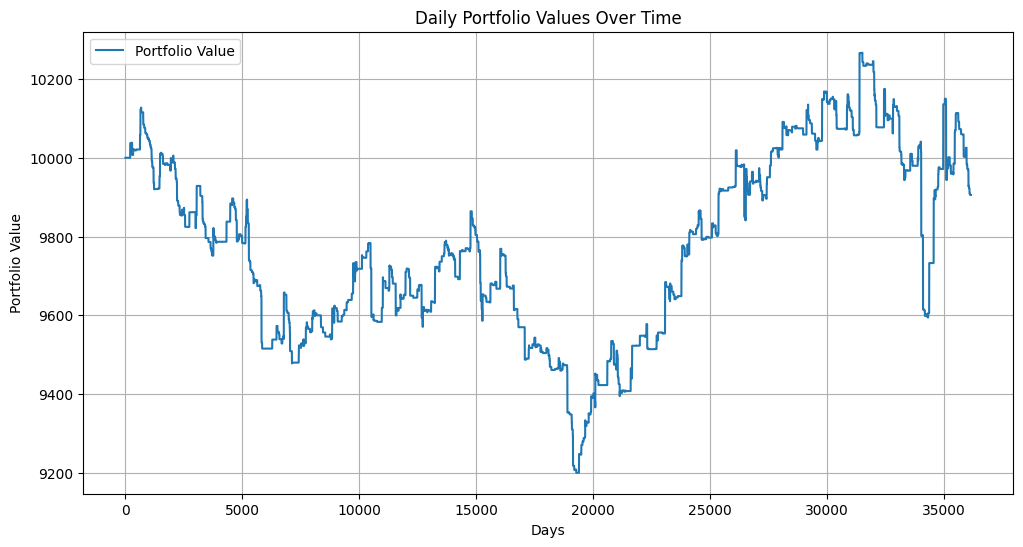

In [ ]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
w_history=[]

fraction=0.5
window_size=1000
fract_max_cash = fraction * initial_cash
for i in range(len(X_test)):

    w=[]
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]

    if row["Prediction"] == 1:
        if not positions and 0.25*cash > price:
            # Buy
            positions[ticker] = (price, 0.25*cash//price)
            cash = cash- price*positions[ticker][1]
            trade+=1
            #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        elif ticker not in positions:
            corr_tickers=list(positions.keys())
            
            df_filtered = df_wide[df_wide['Ticker'].isin(corr_tickers+[ticker])].loc[len(df_wide)-len(X_test)-2+i-window_size:len(df_wide)-len(X_test)-2+i]
            # Pivot le DataFrame pour que chaque ticker ait sa propre colonne de prix de clôture 'C'
            df_pivoted = df_filtered.pivot(index='Datetime', columns='Ticker', values='C')
            # Calcul de la corrélation entre les tickers
            correlation_matrix = df_pivoted.corr()
            for j in corr_tickers:
                correlation = correlation_matrix.loc[ticker, j]
                w.append(correlation)  
            mean_w=np.mean(w)** 2
            w=1-abs(mean_w)
            w_history.append(w)
            max_cash = w * fract_max_cash
            max_cash = max(0, max_cash)
            if max_cash > price:
                if cash>max_cash:
                    positions[ticker] = (price, max_cash // price)
                else:
                    positions[ticker] = (price, cash//price)
                cash = cash- price*positions[ticker][1]
                trade+=1
                #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")   
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        if price/positions[ticker][0]*100-100 >5:
            print(positions[ticker],price,ticker)
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation optimisée Livio basé sur la corrélation

cash:7306.267429828644, trade:869,portefeuille:9702.967319965363
rentabilité:-2.9703268003463745%
Rentabilité annuelle estimée : -0.07261210754696512%


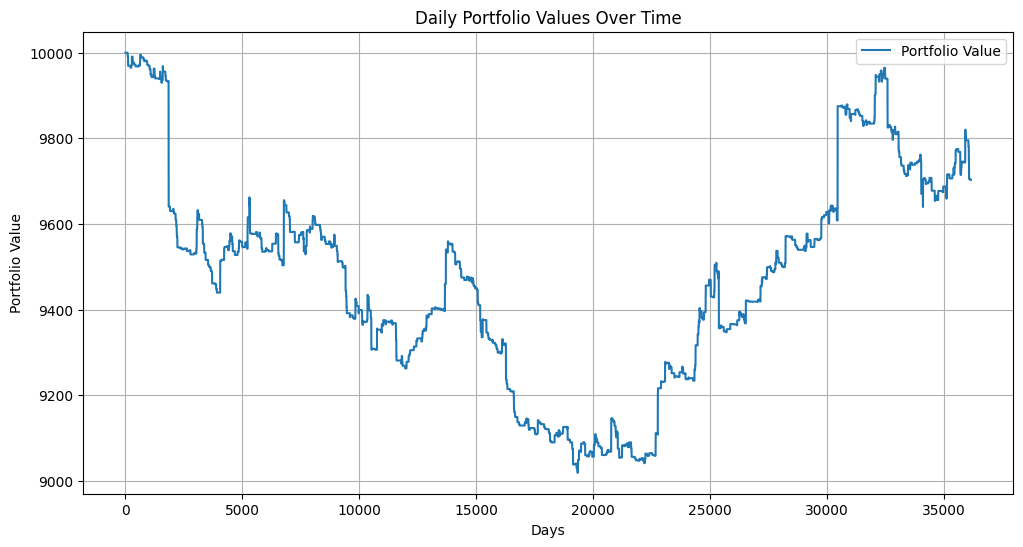

In [ ]:
# Simulation parameters
trade=0
cash = initial_cash
cash_history=[cash]
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, action)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
date_last=df_wide.iloc[len(df_wide)-len(X_test)-2]["Datetime"]
tempdate=None
signal={} #stocke les signaux d'achat pour optimiser la correlation{ticker: (achat_prix, correlation)}
fraction=0.3
window_size=1000
fract_max_cash = fraction * initial_cash
for i in range(len(X_test)):
    tempdate=df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Datetime"]
    w=[]
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    if tempdate!=date_last:
        date_last=tempdate
        if signal:
            bestcorrelation=1
            for ticker_achat,ticker_stats in signal.items():
                if ticker_achat in positions:
                    if len(signal)==1:
                        temp_ticker=ticker_achat
                        temp_ticker_stats=ticker_stats
                        break
                    continue
                if abs(ticker_stats[1])<=bestcorrelation:
                    bestcorrelation=abs(ticker_stats[1])
                    temp_ticker=ticker_achat
                    temp_ticker_stats=ticker_stats
            #Buy
            max_cash = (1-abs(temp_ticker_stats[1])) * fraction* cash
            if cash > temp_ticker_stats[0] and max_cash > temp_ticker_stats[0]:
                if cash>max_cash:
                    positions[temp_ticker] = (temp_ticker_stats[0], max_cash // temp_ticker_stats[0])
                else:
                    positions[temp_ticker] = (temp_ticker_stats[0], cash//temp_ticker_stats[0])
                cash = cash- temp_ticker_stats[0]*positions[temp_ticker][1]
                cash_history.append(cash)
                trade+=1
                #print(f"trade n°{trade}:Achat de {positions[temp_ticker][1]} actions à {temp_ticker_stats[0]} pour {temp_ticker}")
        signal={}
    if row["Prediction"] == 1:
        if not positions:
            signal[ticker]=(price,0)
        elif ticker not in positions:
            corr_tickers=list(positions.keys())
            df_filtered = df_wide[df_wide['Ticker'].isin(corr_tickers+[ticker])].loc[len(df_wide)-len(X_test)-2+i-window_size:len(df_wide)-len(X_test)-2+i]
            # Pivot le DataFrame pour que chaque ticker ait sa propre colonne de prix de clôture 'C'
            df_pivoted = df_filtered.pivot(index='Datetime', columns='Ticker', values='C')
            # Calcul de la corrélation entre les tickers
            correlation_matrix = df_pivoted.corr()
            for j in corr_tickers:
                correlation = correlation_matrix.loc[ticker, j]
                w.append(correlation)  
            mean_w=np.mean(w)
            signal[ticker] = (price,mean_w)
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        cash_history.append(cash)
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation optimisé Livio basée sur la proba xgboost

cash:6315.480872869492, trade:862,portefeuille:9230.280830144882
rentabilité:-7.697191698551179%
Rentabilité annuelle estimée : -0.18146493935937735%


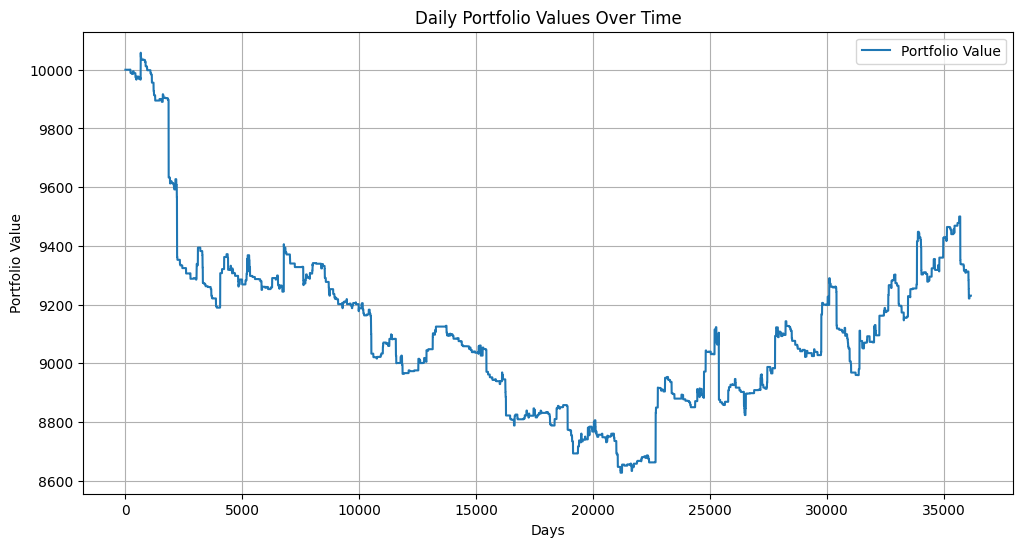

In [ ]:
# Simulation parameters
trade=0
cash = initial_cash
cash_history=[cash]
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, action)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
date_last=df_wide.iloc[len(df_wide)-len(X_test)-2]["Datetime"]
tempdate=None
signal={} #stocke les signaux d'achat pour optimiser la correlation{ticker: (achat_prix, correlation)}
fraction=0.3
window_size=1000
fract_max_cash = fraction * initial_cash
for i in range(len(X_test)):
    tempdate=df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Datetime"]
    w=[]
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    if tempdate!=date_last:
        date_last=tempdate
        if signal:
            bestprob=0
            for ticker_achat,ticker_stats in signal.items():
                if ticker_achat in positions:
                    continue
                if ticker_stats[2]>bestprob:
                    bestprob=ticker_stats[2]
                    temp_ticker=ticker_achat
                    temp_ticker_stats=ticker_stats
            #Buy
            max_cash = (1-abs(temp_ticker_stats[1])) * fract_max_cash
            if max_cash > temp_ticker_stats[0]:
                if cash>max_cash:
                    positions[temp_ticker] = (temp_ticker_stats[0], max_cash // temp_ticker_stats[0])
                else:
                    positions[temp_ticker] = (temp_ticker_stats[0], cash//temp_ticker_stats[0])
                cash = cash- temp_ticker_stats[0]*positions[temp_ticker][1]
                cash_history.append(cash)
                trade+=1
                #print(f"trade n°{trade}:Achat de {positions[temp_ticker][1]} actions à {temp_ticker_stats[0]} pour {temp_ticker}")
        signal={}
    if row["Prediction"] == 1:
        if not positions:
            signal[ticker]=(price,0,row['Prediction_hausse'])
        elif ticker not in positions:
            corr_tickers=list(positions.keys())
            df_filtered = df_wide[df_wide['Ticker'].isin(corr_tickers+[ticker])].loc[len(df_wide)-len(X_test)-2+i-window_size:len(df_wide)-len(X_test)-2+i]
            # Pivot le DataFrame pour que chaque ticker ait sa propre colonne de prix de clôture 'C'
            df_pivoted = df_filtered.pivot(index='Datetime', columns='Ticker', values='C')
            # Calcul de la corrélation entre les tickers
            correlation_matrix = df_pivoted.corr()
            for j in corr_tickers:
                correlation = correlation_matrix.loc[ticker, j]
                w.append(correlation)  
            mean_w=np.mean(w)
            signal[ticker] = (price,mean_w,row['Prediction_hausse'])
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        cash_history.append(cash)
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

cash:7595.422500848777, trade:900,portefeuille:10526.102638483055
rentabilité:5.261026384830548%
Rentabilité annuelle estimée : 0.13676056997472563%


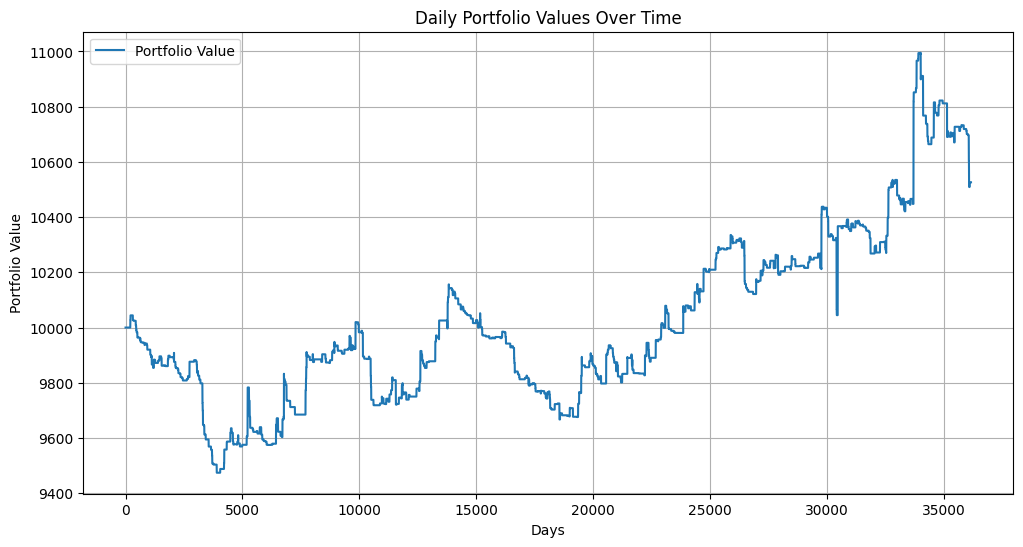

In [ ]:
import random
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, action)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
date_last=df_wide.iloc[len(df_wide)-len(X_test)-2]["Datetime"]
tempdate=None
signal={} #stocke les signaux d'achat pour optimiser la correlation{ticker: (achat_prix, correlation)}
fraction=0.3
window_size=1000
fract_max_cash = fraction * initial_cash
for i in range(len(X_test)):
    tempdate=df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Datetime"]
    w=[]
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    if tempdate!=date_last:
        date_last=tempdate
        if signal:
            temp_list=list(signal.keys())
            temp_choice=temp_list[random.randint(0,len(temp_list)-1)]
            temp_ticker=temp_choice
            temp_price=signal[temp_choice]
            #Buy
            max_cash =  fract_max_cash
            if max_cash > temp_price:
                if cash>max_cash:
                    positions[temp_ticker] = (temp_price, max_cash // temp_price)
                else:
                    positions[temp_ticker] = (temp_price, cash//temp_price)
                cash = cash- temp_price*positions[temp_ticker][1]
                trade+=1
                #print(f"trade n°{trade}:Achat de {positions[temp_ticker][1]} actions à {price} pour {temp_ticker}")
        signal={}
    if row["Prediction"] == 1:
        if not positions:
            signal[ticker]=price
        elif ticker not in positions:
            signal[ticker] =price
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        cash_history.append(cash)
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {price/positions[ticker][0]*100-100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

In [ ]:
df_wide[df_wide["Ticker"]=="AC.PA"].describe()

,C,H,L,O,V,ROC_10,ROC_10_normalized
count,4575.000000,4575.000000,4575.000000,4575.000000,4575.00000,4565.000000,4565.000000
mean,37.527468,37.624498,37.425150,37.524487,31248.19694,0.101043,0.000219
std,5.570114,5.582645,5.557155,5.569622,26928.15891,1.471230,0.003190
min,27.930000,28.150000,27.709999,27.719999,0.00000,-7.085022,-0.015360
25%,32.914999,32.980000,32.820000,32.910000,14117.50000,-0.698238,-0.001514
50%,37.099998,37.180000,37.020000,37.099998,25762.00000,0.173504,0.000376
75%,41.529999,41.605000,41.400002,41.520000,42481.00000,0.979593,0.002124
max,51.020000,51.099998,50.900002,51.040001,286966.00000,7.561694,0.016394


cash:11046.449249267578, trade:4623,portefeuille:433046.062694788
rentabilité:4230.46062694788%
Rentabilité annuelle estimée : 12339.570452025991%


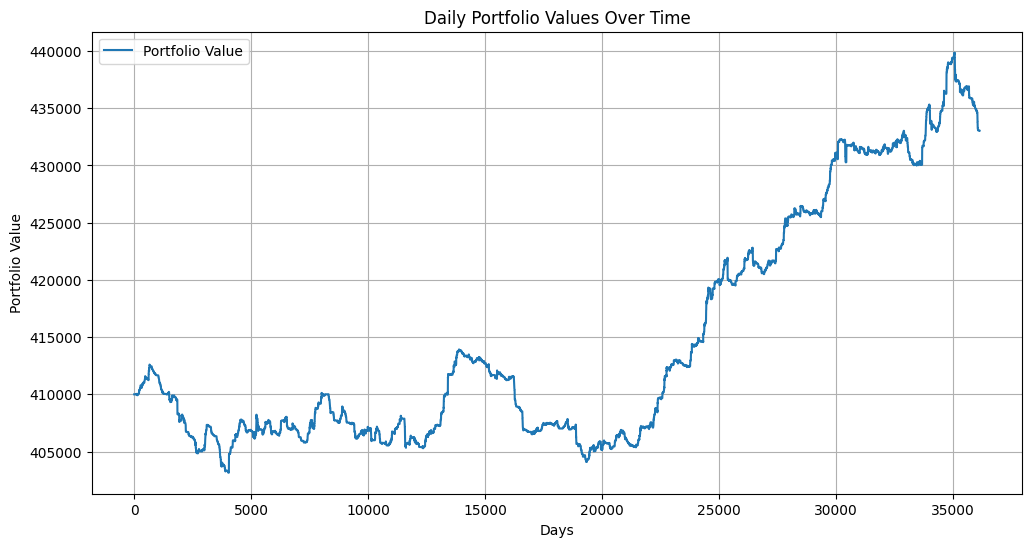

In [ ]:
# Simulation parameters
cash_l={}
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    if ticker not in cash_l:
        cash_l[ticker]=[initial_cash]
    cash=cash_l[ticker][-1]
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        cash_l[ticker].append(cash)
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        cash_l[ticker].append(cash)
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(sum([a[-1] for a in cash_l.values()])+10000*(41-len(cash_l)) + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")
for ticker,ticker_stats in positions.items():
    cash_l[ticker].append(cash_l[ticker][-1] + ticker_stats[0]*ticker_stats[1])
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


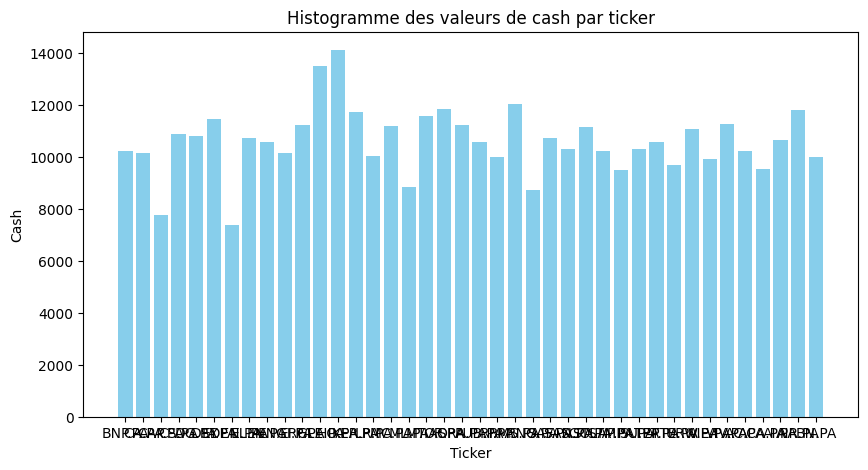

In [ ]:
# Extraction des clés et valeurs
tickers = list(cash_l.keys())
cash_values = list(a[-1] for a in cash_l.values())

# Création du graphique
plt.figure(figsize=(10, 5))
plt.bar(tickers, cash_values, color='skyblue')

# Ajout des titres et labels
plt.xlabel("Ticker")
plt.ylabel("Cash")
plt.title("Histogramme des valeurs de cash par ticker")

# Affichage
plt.show()

[1.40942008 1.34733338 1.2002     1.18274469 1.18073638 1.17072521
 1.15508078 1.14280134 1.12703521 1.12143944 1.11974139 1.11736971
 1.11462192 1.10464492 1.08626157 1.07989006 1.07284519 1.07155987
 1.06310009 1.05686415 1.05491224 1.05472766 1.02854779 1.02765786
 1.02071607 1.02011449 1.01969121 1.01538279 1.01282952 1.00308968]


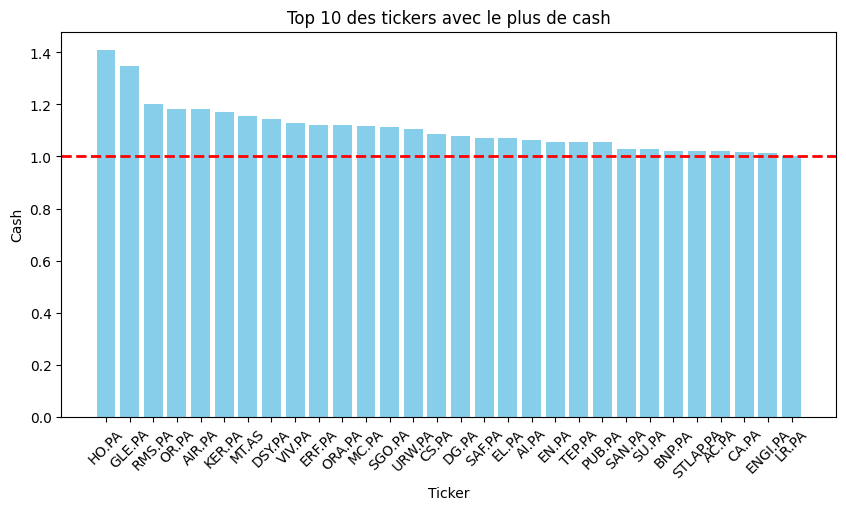

In [ ]:
top_10 = dict(sorted(cash_l.items(), key=lambda item: item[1][-1], reverse=True)[:30])

# Extraction des clés et valeurs
tickers = list(top_10.keys())
cash_values = np.array(list(a[-1] for a in top_10.values()))
cash_values= cash_values/10000
print(cash_values)
# Création du graphique
plt.figure(figsize=(10, 5))
plt.bar(tickers, cash_values, color='skyblue')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2)
# Ajout des titres et labels
plt.xlabel("Ticker")
plt.ylabel("Cash")
plt.title("Top 10 des tickers avec le plus de cash")

# Rotation des labels pour lisibilité
plt.xticks(rotation=45)

# Affichage
plt.show()

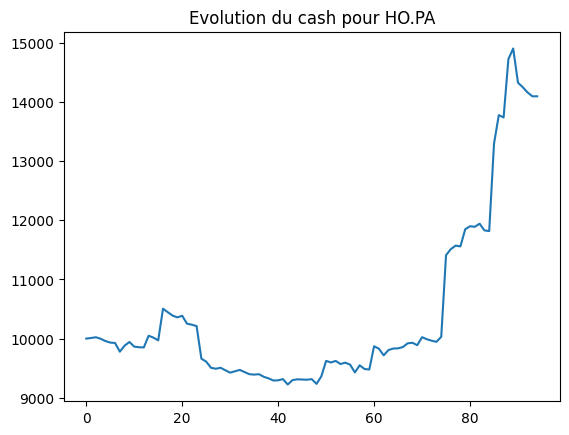

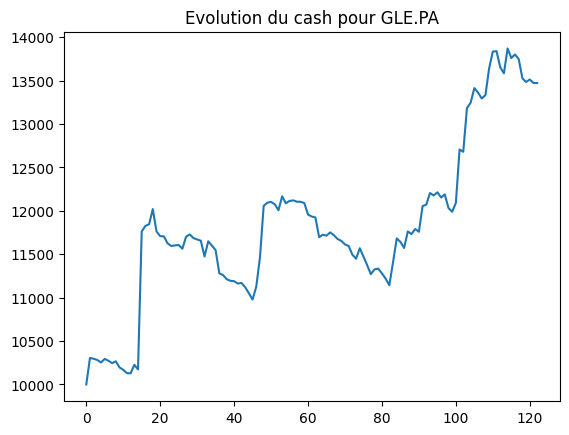

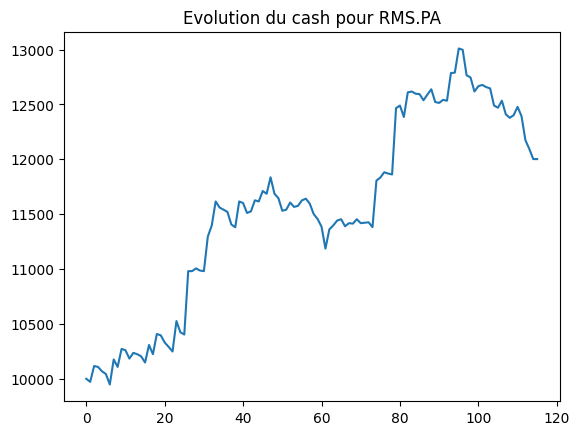

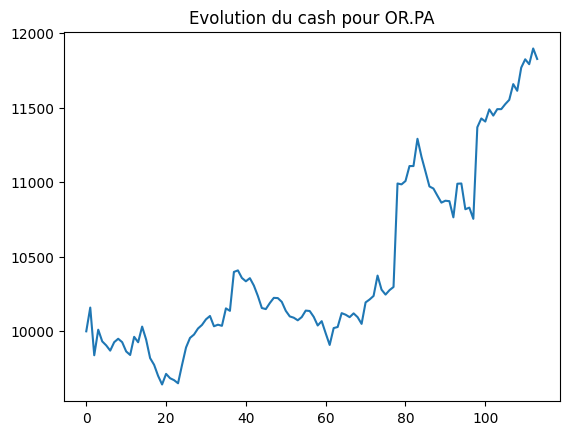

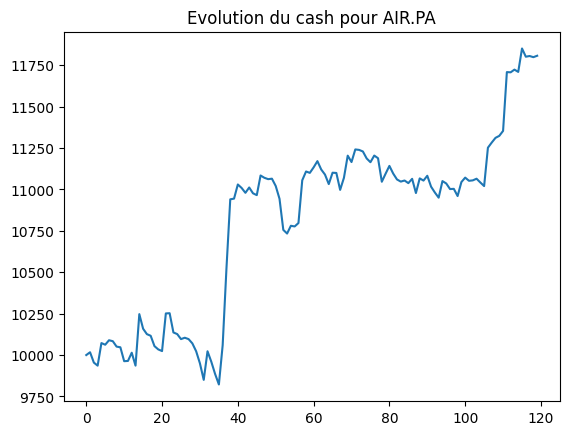

In [ ]:
top_10 = dict(sorted(cash_l.items(), key=lambda item: item[1][-1], reverse=True)[:5])
for ticker,cash in top_10.items():
    cash=[a for a in cash if a >5000]
    plt.plot(cash)
    plt.title(f"Evolution du cash pour {ticker}")
    plt.show()

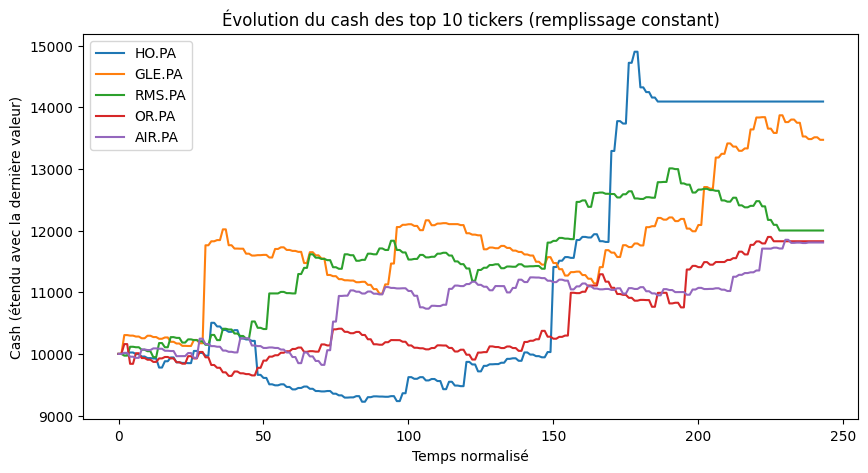

In [ ]:
max_length = max(len(cash) for cash in top_10.values())

# Fonction pour étendre une liste en répétant la dernière valeur
def extend_list(lst, target_length):
    return lst + [lst[-1]] * (target_length - len(lst))

# Appliquer l'extension à toutes les séries
top_10_extended = {ticker: extend_list(cash, max_length) for ticker, cash in top_10.items()}

# Tracer les courbes après homogénéisation
plt.figure(figsize=(10, 5))

for ticker, cash in top_10_extended.items():
    cash=[cash[i] if cash[i] > 5000 else cash[i - 1]for i in range(0,len(cash)-1)]
    plt.plot(cash, label=ticker)

# Ajouter une légende et des labels
plt.legend()
plt.xlabel("Temps normalisé")
plt.ylabel("Cash (étendu avec la dernière valeur)")
plt.title("Évolution du cash des top 10 tickers (remplissage constant)")

# Afficher le graphique
plt.show()